# Global Terrorism Database (GTD) - Exploratory Data Analysis and Data Visualization

This project analyzes terrorism incidents across the world using the [Global Terrorism Database (GTD)](https://www.start.umd.edu/gtd/). The dataset includes detailed information on terrorist events from 1970 to mid-2021.

We'll be performing exploratory data analysis, cleaning inconsistencies, and exploring trends through visualization.

## 🛠️ Environment Setup & Loading Datasets

We are using 2 datasets, one is the main dataset that covers incidents from 1970 to 2020 and the other is an extension of that dataset that covers events that occurred between January and June 2021.

We'll be loading and concatenating these into a single DataFrame for analysis.

In [149]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style= "whitegrid")
sns.set_palette("Set2")

#Ensures all plots are displayed in the notebook.
%matplotlib inline

#Setting the maximum number of rows and columns displayed on printing.
pd.set_option("display.max_rows",50)
pd.set_option("display.max_columns", 100)

In [150]:
terror_2020 = pd.read_csv(r"data\globalterrorismdb_0522dist.csv", index_col = "eventid")
terror_2021 = pd.read_csv(r"data\globalterrorismdb_2021Jan-June_1222dist.csv", index_col = "eventid")

#Checking shape of each dataframe.
print("GTD (till 2020):",terror_2020.shape)
print("GTD (2021 Jan-June):", terror_2021.shape)

terror = pd.concat([terror_2020,terror_2021])
print("GTD (combined):", terror.shape)

GTD (till 2020): (209706, 134)
GTD (2021 Jan-June): (4960, 134)
GTD (combined): (214666, 134)


## 🔎Dataset Overview

Lets begin by understanding the structure of the dataset.

- Each row is an instance of a terrorist event around the world.
- Each column represents one of the features of the event.

We'll be inspecting for duplicated rows, inconsistent data, and the kind of numeric data in different columns.

In [151]:
print(f"The dataset has {terror.shape[0]} rows and {terror.shape[1]} columns. \n") #To get the number of rows and columns

print("Dataset info:")
print(terror.info(),"\n")

print("Columns: ")
print(terror.columns.tolist(),"\n")

print("Number of duplicated rows:",terror.duplicated().sum() )

print("\nFirst 5 rows: ")
terror.head()

The dataset has 214666 rows and 134 columns. 

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 214666 entries, 197000000001 to 202107020037
Columns: 134 entries, iyear to related
dtypes: float64(54), int64(22), object(58)
memory usage: 221.1+ MB
None 

Columns: 
['iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1', 'crit2', 'crit3', 'doubtterr', 'alternative', 'alternative_txt', 'multiple', 'success', 'suicide', 'attacktype1', 'attacktype1_txt', 'attacktype2', 'attacktype2_txt', 'attacktype3', 'attacktype3_txt', 'targtype1', 'targtype1_txt', 'targsubtype1', 'targsubtype1_txt', 'corp1', 'target1', 'natlty1', 'natlty1_txt', 'targtype2', 'targtype2_txt', 'targsubtype2', 'targsubtype2_txt', 'corp2', 'target2', 'natlty2', 'natlty2_txt', 'targtype3', 'targtype3_txt', 'targsubtype3', 'targsubtype3_txt', 'corp3', 'ta

,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,region_txt,provstate,city,latitude,longitude,specificity,vicinity,location,summary,crit1,crit2,crit3,doubtterr,alternative,alternative_txt,multiple,success,suicide,attacktype1,attacktype1_txt,attacktype2,attacktype2_txt,attacktype3,attacktype3_txt,targtype1,targtype1_txt,targsubtype1,targsubtype1_txt,corp1,target1,natlty1,natlty1_txt,targtype2,targtype2_txt,targsubtype2,targsubtype2_txt,corp2,target2,natlty2,natlty2_txt,targtype3,...,weaptype2,weaptype2_txt,weapsubtype2,weapsubtype2_txt,weaptype3,weaptype3_txt,weapsubtype3,weapsubtype3_txt,weaptype4,weaptype4_txt,weapsubtype4,weapsubtype4_txt,weapdetail,nkill,nkillus,nkillter,nwound,nwoundus,nwoundte,property,propextent,propextent_txt,propvalue,propcomment,ishostkid,nhostkid,nhostkidus,nhours,ndays,divert,kidhijcountry,ransom,ransomamt,ransomamtus,ransompaid,ransompaidus,ransomnote,hostkidoutcome,hostkidoutcome_txt,nreleased,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
eventid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,Central America & Caribbean,National,Santo Domingo,18.456792,-69.951164,1.0,0,NaN,NaN,1,1,1,0,NaN,NaN,0.0,1,0,1,Assassination,NaN,NaN,NaN,NaN,14,Private Citizens & Property,68.0,Named Civilian,NaN,Julio Guzman,58.0,Dominican Republic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,North America,Federal,Mexico city,19.371887,-99.086624,1.0,0,NaN,NaN,1,1,1,0,NaN,NaN,0.0,1,0,6,Hostage Taking (Kidnapping),NaN,NaN,NaN,NaN,7,Government (Diplomatic),45.0,"Diplomatic Personnel (outside of embassy, cons...",Belgian Ambassador Daughter,"Nadine Chaval, daughter",21.0,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,NaN,Mexico,1.0,800000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,Southeast Asia,Tarlac,Unknown,15.478598,120.599741,4.0,0,NaN,NaN,1,1,1,0,NaN,NaN,0.0,1,0,1,Assassination,NaN,NaN,NaN,NaN,10,Journalists & Media,54.0,Radio Journalist/Staff/Facility,Voice of America,Employee,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,Western Europe,Attica,Athens,37.997490,23.762728,1.0,0,NaN,NaN,1,1,1,0,NaN,NaN,0.0,1,0,3,Bombing/Explosion,NaN,NaN,NaN,NaN,7,Government (Diplomatic),46.0,Embassy/Consulate,NaN,U.S. Embassy,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Explosive,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,East Asia,Fukouka,Fukouka,33.580412,130.396361,1.0,0,NaN,NaN,1,1,1,-9,NaN,NaN,0.0,1,0,7,Facility/Infrastructure Attack,NaN,NaN,NaN,NaN,7,Government (Diplomatic),46.0,Embassy/Consulate,NaN,U.S. Consulate,217.0,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Incendiary,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


## 🧹 Dataset Cleaning

From the overview we have understood that the GTD dataset is complex and large with 134 columns and 200,000+ entries, including a mix of textual, numerical and date-related data.

Before conducting any analysis we must ensure that the data is tidy, consistent, and relevant to our goal.


### Checking for missing values
Lets look for columns with a large number of missing values to decide what to drop or keep.

In [152]:
null_counts = terror.isnull().sum() # returns a series with each column and number of nulls
sorted_null_counts = terror.isnull().sum().sort_values(ascending=False)

total_null_count = null_counts.sum()
total_cell_count = terror.shape[0] * terror.shape[1]
total_null_percent = (total_null_count/total_cell_count)*100 # will give the percentage of the null cells in entire dataset.

print("The percentage of null entries in the GTD dataset is:", total_null_percent)

null_percent = (sorted_null_counts / len(terror)) * 100
missing_df = pd.DataFrame({'Missing Values': sorted_null_counts, 'Percent': null_percent})
missing_df[missing_df['Missing Values'] > 0]

columns_mtm50 = missing_df[missing_df.Percent >50].index
spared_columns = ['divert','ransomnote','ransompaidus','ransomamtus', 'ransompaid','ransomamt','resolution','compclaim', 'nhours', 'gsubname','ndays','nreleased','natlty2_txt', 'natlty2','related', 'alternative', 'alternative_txt','propvalue', 'motive', 'propcomment', 'location','propextent', 'propextent_txt', 'ransom']
columns_to_drop = [col for col  in columns_mtm50 if col not in spared_columns]
#dropping columns with more that 50% missing percent.
print(f"\nDropped {len(columns_to_drop)} columns.")
print("Dropped columns:", columns_to_drop)

#terror.drop(columns=columns_to_drop, inplace =True) 

The percentage of null entries in the GTD dataset is: 56.348067132682765

Dropped 53 columns.
Dropped columns: ['gsubname3', 'weapsubtype4', 'weapsubtype4_txt', 'weaptype4_txt', 'weaptype4', 'claimmode3', 'claimmode3_txt', 'gsubname2', 'claim3', 'guncertain3', 'gname3', 'attacktype3', 'attacktype3_txt', 'claimmode2', 'claimmode2_txt', 'corp3', 'targsubtype3_txt', 'targsubtype3', 'natlty3_txt', 'natlty3', 'target3', 'targtype3', 'targtype3_txt', 'weapsubtype3', 'weapsubtype3_txt', 'weaptype3', 'weaptype3_txt', 'claim2', 'guncertain2', 'gname2', 'kidhijcountry', 'attacktype2', 'attacktype2_txt', 'approxdate', 'corp2', 'hostkidoutcome_txt', 'hostkidoutcome', 'targsubtype2_txt', 'targsubtype2', 'weapsubtype2_txt', 'weapsubtype2', 'target2', 'targtype2_txt', 'targtype2', 'weaptype2', 'weaptype2_txt', 'nhostkidus', 'nhostkid', 'claimmode', 'claimmode_txt', 'addnotes', 'scite3', 'scite2']


We've dropped 53 columns that were selected on the basis of having more than 50% null percent. Some columns that have necessary information were spared. (can be found in list spared_columns)

### Fixing Dates

In [153]:
#Lets display the date fields in the dataframe.

print(terror[["iyear","iday","imonth","approxdate"]].head())

              iyear  iday  imonth approxdate
eventid                                     
197000000001   1970     2       7        NaN
197000000002   1970     0       0        NaN
197001000001   1970     0       1        NaN
197001000002   1970     0       1        NaN
197001000003   1970     0       1        NaN


Here we can see that the "approxdate" column is basically the iyear, iday and imonth in a date format.

So let's work on renaming the "approxdate" column to "eventdate" and parse the content from iyear, imonth and iday to the "eventdate" field as datetime format.

In [154]:
#Displaying the value counts for each unique entry in the iyear, imonth and iday columns.

print(terror.imonth.value_counts().sort_index().head())
print(terror.iday.value_counts().sort_index().head())
print(terror.iyear.value_counts().sort_index().head())
print(terror.iyear.value_counts().sort_index().tail())

imonth
0       20
1    18062
2    16755
3    18285
4    18393
Name: count, dtype: int64
iday
0     891
1    7366
2    7014
3    7048
4    7214
Name: count, dtype: int64
iyear
1970    651
1971    471
1972    567
1973    473
1974    581
Name: count, dtype: int64
iyear
2017    11364
2018     9853
2019     8537
2020     8438
2021     4960
Name: count, dtype: int64


Here we can see that in both "iyear" and "imonth" columns there are 0 entries which likely denote the first day of the month, so well focus on changing those entries to 1 for seamless date parsing.

In [155]:
terror["imonth"] = terror["imonth"].replace(0,1)
terror["iday"] = terror["iday"].replace(0,1)

Now we can work on parsing the dates to the "approxdate" column and rename it to "eventdate"

In [156]:
#renaming approxdate to eventdate and iyear, imonth and iday to match pandas requirement for parsing
terror.rename(columns={"approxdate":"eventdate", "iyear":"year","imonth":"month","iday":"day"}, inplace=True)

terror["eventdate"] =pd.to_datetime(terror[["year","month","day"]], errors="coerce") #when giving dataframe columns as input, pandas automatically assumes the fields are year, month and date.

#checking how many dates are null
terror.eventdate.isna().sum()

np.int64(0)

There are 0 null entries in `eventdate`. This means the parsing was successful and we can move on.

### Changing DataTypes

Some columns in the GTD Dataset might need datatype conversions to work with the data, lets find out what those columns are and how we can edit them.

In [157]:
# To view all columns with respective datatypes
print(terror.dtypes)

#We are parsing the resolution column to datetime format.
terror.resolution.unique()
terror["resolution"] = pd.to_datetime(terror["resolution"], format= "%d/%m/%Y", errors="coerce")

year                  int64
month                 int64
day                   int64
eventdate    datetime64[ns]
extended              int64
                  ...      
INT_LOG               int64
INT_IDEO              int64
INT_MISC              int64
INT_ANY               int64
related              object
Length: 134, dtype: object


To ensure all the columns are the appropriate datatypes, we've gone through the datatypes of all columns and changed those that require parsing.

### Drop Duplicates

We will be checking the entries in the dataset and dropping duplicate rows based on eventid.

In [158]:
print("Number of duplicate entries:", terror.duplicated().sum())
terror = terror.drop_duplicates()

Number of duplicate entries: 9068


### Summary

In this section we have:

- Identified columns with **high percentages of missing values (>50%)** and dropped them to reduce noise.
- Carefully **excluded important columns** such as `ransomnote` and `ransompaid` from removal.
- Inspected data types for all columns and planned for **datatype conversions** where necessary to optimize memory and analysis.
- Parsed the `iyear`, `imonth`, and `iday` columns to create a new `approxdate` column, then **renamed it to `eventdate`**, to handle missing or invalid dates.
- Checked for and removed **fully duplicated rows** (~9,000 duplicates), ensuring each event is unique.


## 📈 Exploratory Data Analysis and Observations

In this section, we'll explore individual features from the GTD to understand their distributions and identify patterns.

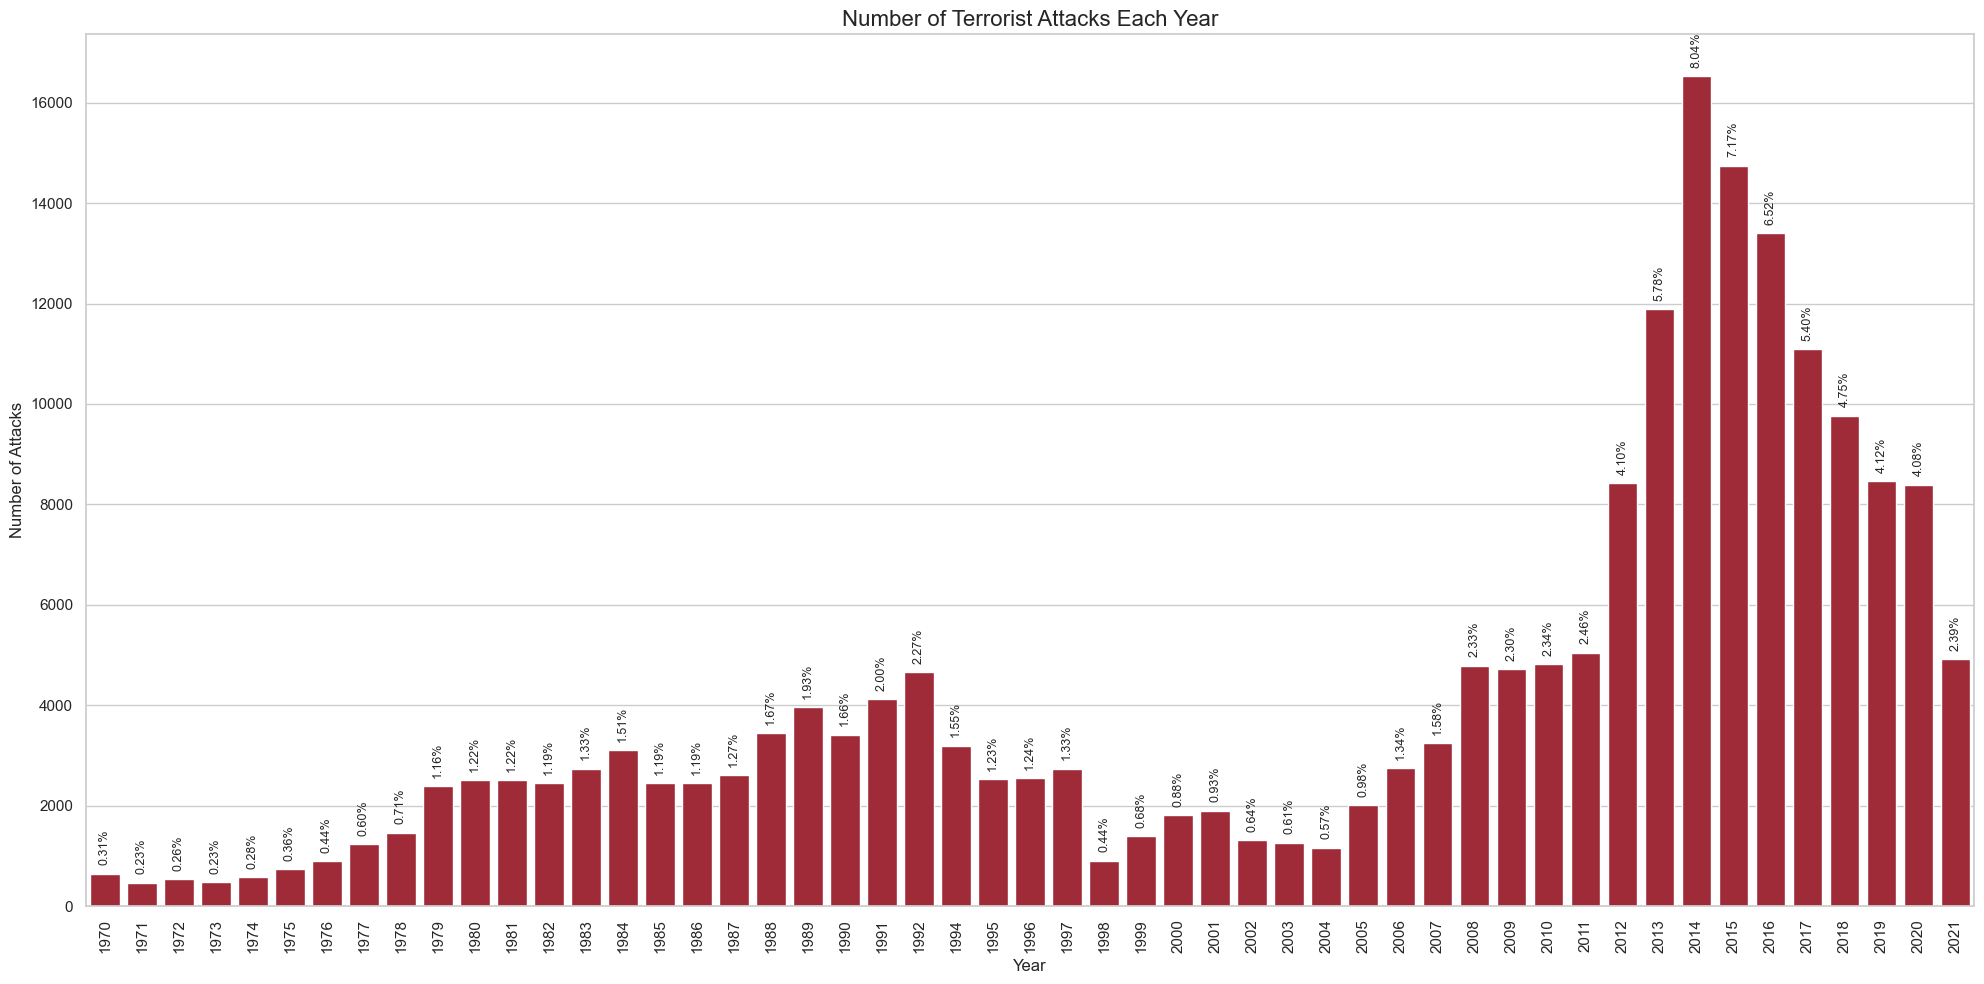

In [159]:

PRIMARY_COLOR = "#b2182b"

# Total number of attacks
total_attacks = len(terror)

# Count attacks per year
year_counts = terror["year"].value_counts().sort_index()

# Convert to percentages
year_percentages = (year_counts / total_attacks) * 100

plt.figure(figsize=(20, 10))
ax = sns.countplot(data=terror, x="year", color=PRIMARY_COLOR)

plt.title("Number of Terrorist Attacks Each Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=90)

# Annotate bars with percentages
for i, year in enumerate(year_counts.index):
    count = year_counts.loc[year]
    percent = year_percentages.loc[year]
    ax.text(
        i,
        count + (0.01 * max(year_counts)),  # small offset above bar
        f"{percent:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=90
    )

plt.tight_layout()
plt.show()

**Observation:**
We can see that the number of terrorist attacks around the world saw an abnormal increase after the year 2011, with an all time peak of 16,000+ attacks in 2014. The graph shows a steady decline in the years post-2014.
In the 20th century, we can see an out of pattern jump in incidents between the years 1988 and 1994 after which the years 1998 - 2004 saw the least number of terrorist events.

### Attack Method

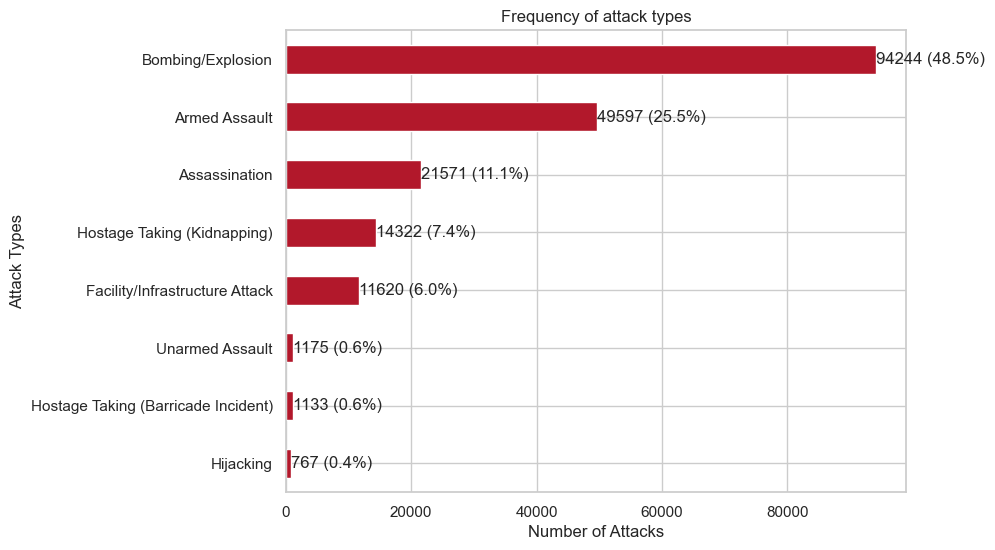

In [160]:
#Lets look at the top attack methods with the percentage of how often it occurred.
atk_counts = terror["attacktype1_txt"].value_counts(dropna=False)
atk_counts = atk_counts.drop('Unknown')

#Plotting the top attacktypes.
axes = atk_counts.sort_values().plot(kind = 'barh',figsize=(8,6), color=PRIMARY_COLOR) # returns axes object

axes.set_xlabel(r"Number of Attacks")
axes.set_ylabel("Attack Types")   
axes.set_title("Frequency of attack types")


for i, v in enumerate(atk_counts.sort_values()):
    atk_percent = v / atk_counts.sum() * 100
    axes.text(v + 5, i, f"{v} ({atk_percent:.1f}%)", va='center')




**Observation:**
Terrorist attacks with the use of explosives is the most frequent attack type, covering almost 46% of the total attacks recorded. Armed assault is the second most frequent with 24% and other methods like assassination, hostage taking and infrastructure attacks trail behind with lesser frequencies.

### Weapon Types
Now that we looked at the attack types, lets analyze what are the most common weapons used.

In [161]:
#First lets see how often the weapon type is specified in the dataset.
unknown_weap = (terror["weaptype1_txt"]=="Unknown").sum()
unknown_perc = ((unknown_weap/terror["weaptype1_txt"].count()) *100).round(2)

print(f"There are {unknown_weap} entries with the weapon type specified as unknown, \nwhich amounts to {unknown_perc}% of the total data.")


There are 20299 entries with the weapon type specified as unknown, 
which amounts to 9.87% of the total data.


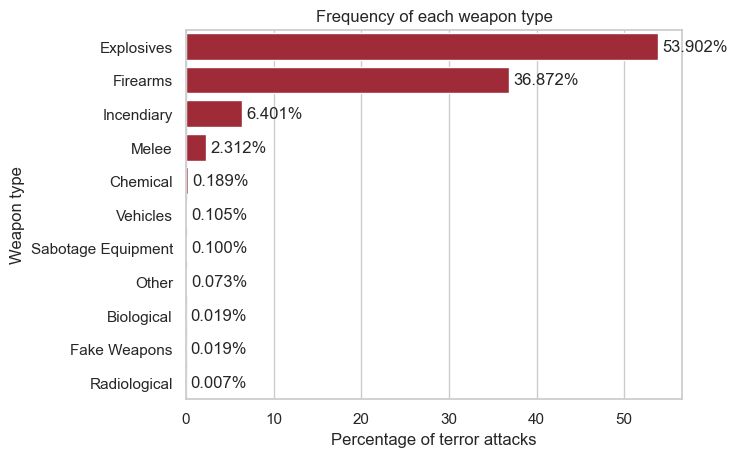

In [162]:
#Now lets plot a bargraph for the different types of weapons used.
wep_types = terror["weaptype1_txt"].replace(to_replace=r".*Vehicle.*", value="Vehicles", regex=True)
wep_types = wep_types.value_counts()
wep_types = wep_types.drop(["Unknown"])

wep_pct = ((wep_types/wep_types.sum())*100)

ax = sns.barplot(y = wep_pct.index, x = wep_pct.values, color=PRIMARY_COLOR)
plt.title("Frequency of each weapon type")
plt.xlabel("Percentage of terror attacks")
plt.ylabel("Weapon type")
for i, v in enumerate(wep_pct.values):
    ax.text(v + 0.5, i, f"{v:.3f}%", va='center')



**Observation:**
By analyzing the type of weapons used, we can see that more than half of the terrorist attacks were carried out with explosives, with the majority of attacks being carried out with either explosives or firearms.

Out of all the entries, 9.9% of the data had the weapon type specified as "Unknown".

#### Weapon Prevalence by Geography

Do certain geographies favor certain weapon types, and does this choice affect the lethality?

Variables used:
- Weapon Type
- Region

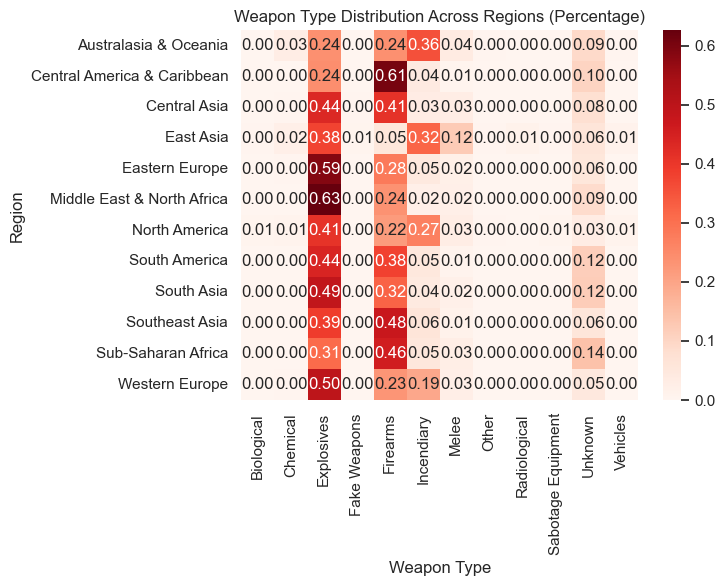

In [163]:
weapon_region = terror.groupby(["region_txt","weaptype1_txt"]).size().reset_index(name="count")
weapon_region["weaptype1_txt"] = weapon_region["weaptype1_txt"].replace(to_replace=r".*Vehicle.*", value="Vehicles", regex=True)

weapon_region_pivot = weapon_region.pivot(index="region_txt", columns="weaptype1_txt", values="count").fillna(0)
weapon_region_pct = weapon_region_pivot.div(weapon_region_pivot.sum(axis=1), axis=0)

plt.Figure(figsize=(15,8))
sns.heatmap(weapon_region_pct, cmap="Reds", annot=True, fmt=".2f")
plt.title("Weapon Type Distribution Across Regions (Percentage)")
plt.xlabel("Weapon Type")
plt.ylabel("Region")
plt.show()

**Observation:**
Across most regions, explosives are the most commonly used weapon type. The Central America & Caribbean, Southeast Asia, and Sub-Saharan Africa regions show a notable prevalence of firearms as the primary weapon. In contrast, Australia, East Asia, and North America exhibit higher frequencies of incendiary attacks.

Regions with a wide variety of weapon types tend to indicate high-intensity or prolonged conflicts, whereas regions with limited weapon diversity may reflect tactical constraints or resource limitations.

##### Geographic Incendiary Attack Trends

Lets analyze trends of Incendiary attacks and see if we can derive some kind of pattern.

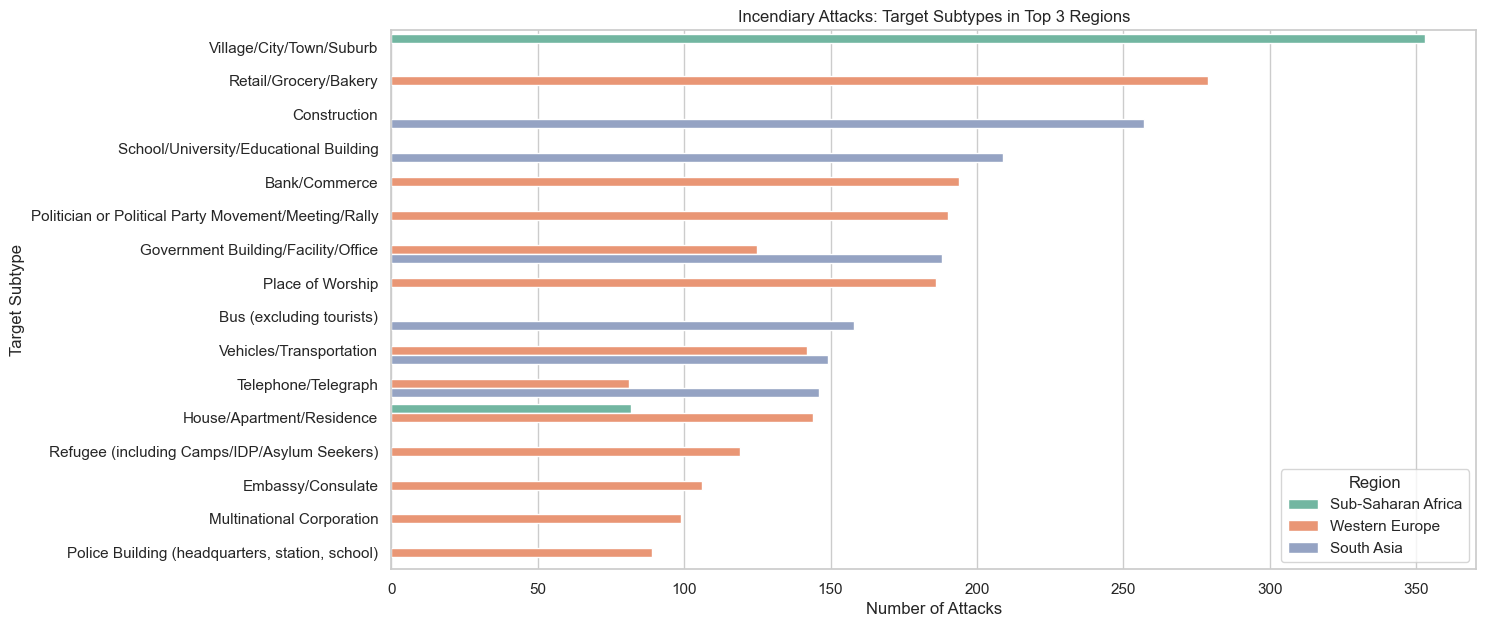

In [164]:
incendiary_attacks = terror[terror["weaptype1_txt"] == "Incendiary"]

top_regions = (
    incendiary_attacks
    .groupby("region_txt")
    .size()
    .sort_values(ascending=False)
    .head(3)
    .index
)

incendiary_top_regions = incendiary_attacks[incendiary_attacks["region_txt"].isin(top_regions)]

incendiary_targets = (
    incendiary_top_regions
    .groupby(["region_txt", "targtype1_txt", "targsubtype1_txt"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(14,7))
sns.barplot(
    data=incendiary_targets.head(20),  # Top 20 most frequent combinations
    x="count",
    y="targsubtype1_txt",
    hue="region_txt"
)
plt.title("Incendiary Attacks: Target Subtypes in Top 3 Regions")
plt.xlabel("Number of Attacks")
plt.ylabel("Target Subtype")
plt.legend(title="Region")
plt.show()

**Observation:**

From this plot, we can observe:

- Incendiary attacks in **Sub-Saharan Africa** was mainly focused on places of **residence** in villages/towns. 
- Incendiary attacks in **South Asia** were focused on **public infrastructure** like Government buildings, schools and buses.
- Incendiary attacks in **Western Europe** are **spread around** and don't show a specific target or pattern.

### Terror attacks by Geography

First lets look at terror attacks by region:

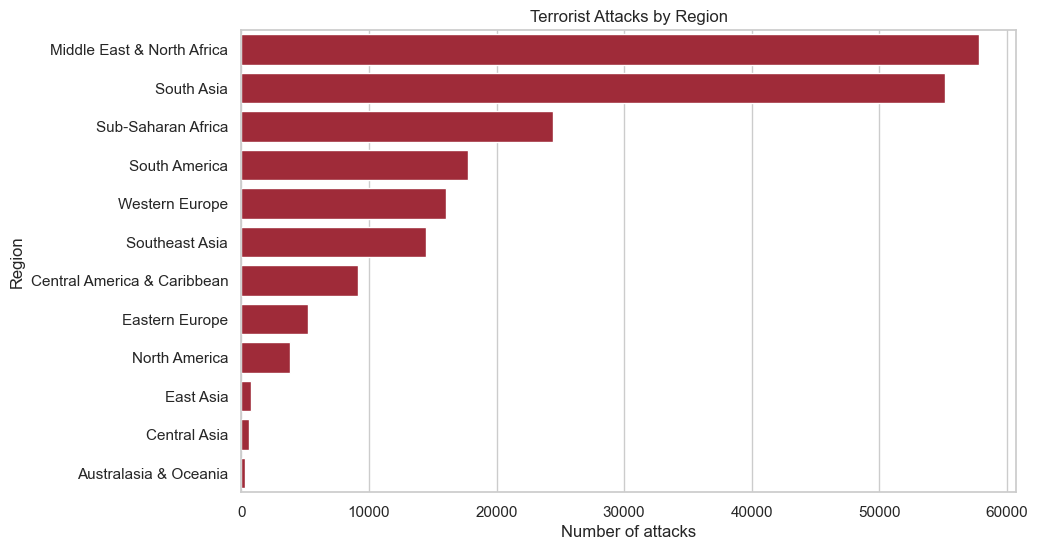

In [165]:
# Count attacks per region
region_counts = terror['region_txt'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=region_counts.values, y=region_counts.index,color=PRIMARY_COLOR)
plt.xlabel("Number of attacks")
plt.ylabel("Region")
plt.title("Terrorist Attacks by Region")
plt.show()

Lets see what the top 15 countries are in terms of number of attacks.

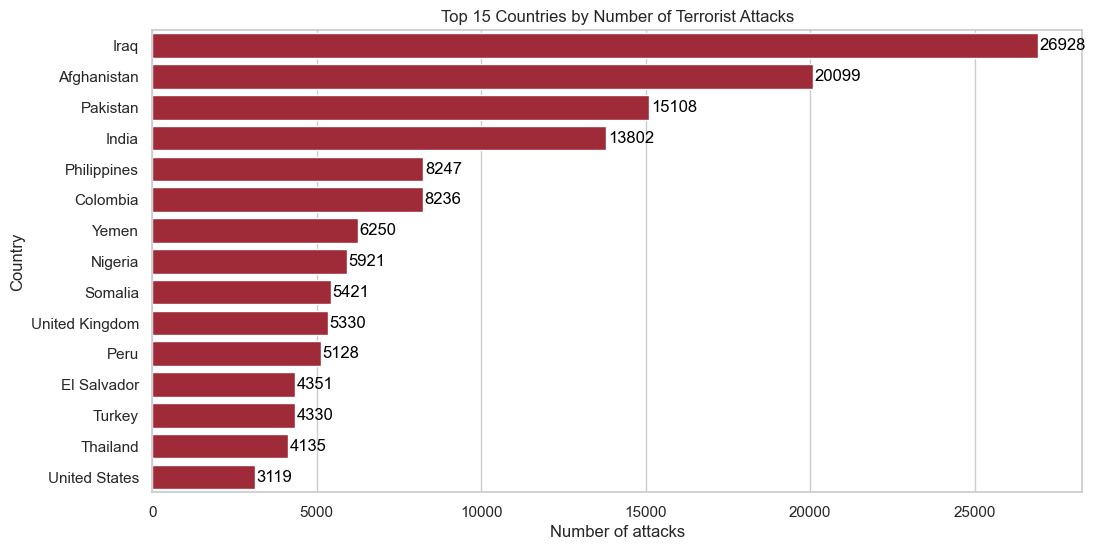

In [166]:
# Top 15 countries
top_countries_overall = terror['country_txt'].value_counts().head(15)

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top_countries_overall.values, y=top_countries_overall.index,color=PRIMARY_COLOR)
plt.xlabel("Number of attacks")
plt.ylabel("Country")
plt.title("Top 15 Countries by Number of Terrorist Attacks")

for i, v in enumerate(top_countries_overall.values):
    ax.text(v + 50, i, str(v), color='black', va='center') 
    
plt.show()

#### Heatmap of attacks by Country (2010-2018)
Lets visualize the terror trends over years with a heatmap showing the number of attacks in the top 25 countries per year from 2010-2018.

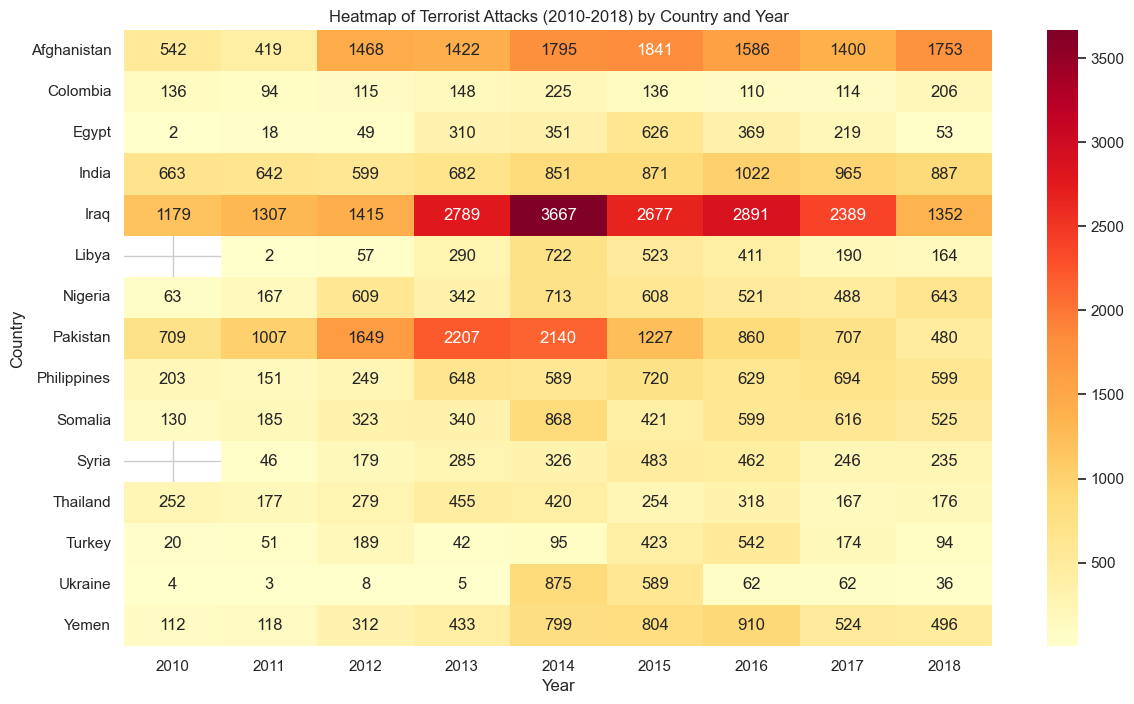

In [167]:
#Creating a new dataframe for attacks from 2010-2018
terror_2010to18 = terror[(terror["year"] >=2010) & (terror["year"] <= 2018)]

#lets get the countries with most number of attacks in this time period.
top_countries_2010to18 = terror_2010to18["country_txt"].value_counts().nlargest(15)

#creating a dataframe for only the top 15 countries
terror_heatmap = terror_2010to18[terror_2010to18["country_txt"].isin(top_countries_2010to18.index.tolist())]

#creating a pivot table for the heatmap
heatmap_data = terror_heatmap.pivot_table(index='country_txt', columns='year', values="eventdate", aggfunc='count')

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='g')
plt.title("Heatmap of Terrorist Attacks (2010-2018) by Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

**Observation:**
The heatmap reveals information like the peak of terror activity in the years 2013-2015 in countries like Afghanistan, Iraq and Pakistan.

The plot also shows **intermittent spikes** in countries like Somalia (2014), Yemen(2014-2016) and Libya (2014).

We can see that countries like Columbia and India show equal levels of attack counts in all years, reflecting ongoing regional conflicts. 

This visualization emphasizes how terrorism during this period was highly **regionally concentrated** rather than evenly distributed globally.

#### Adding population information for per capita calculations

We will be adding population information for every country according to the event year to calculate per capita information.

In [168]:
population = pd.read_csv("./data/world_pop.csv")
population= population.drop(columns=["Country Code", "Indicator Name","Indicator Code"])


population_long = population.melt(id_vars='Country Name', var_name='year', value_name='population')
population_long['year'] = population_long['year'].astype(int)

#Merging GTD with world population database
terror = pd.merge(terror, population_long, how = "left", left_on=["country_txt","year"], right_on=["Country Name", "year"])

#Calculating attacks per capita
attacks_per_country_year = (
    terror.groupby(['country_txt', 'year'])
    .size()
    .reset_index(name='attack_count')
)

attacks_per_country_year = attacks_per_country_year.merge(
    population_long, left_on=['country_txt','year'], right_on=['Country Name','year'], how='left'
)

attacks_per_country_year['attacks_per_million'] = attacks_per_country_year['attack_count'] / (attacks_per_country_year['population']/1_000_000)

Lets add a representative population column to the dataset so that we can use a mean population between 1971-2021 to calculate per capita for the entire data instead of relying on yearly calculation.

In [169]:
YEAR_MIN, YEAR_MAX = 1971, 2021

population_long_71to21 =population_long[(population_long['year'] >= YEAR_MIN) & (population_long['year'] <= YEAR_MAX)]



mean_population = (
    population_long_71to21.groupby("Country Name")["population"]
    .mean()
    .reset_index(name="mean_population_1971to21")
)

terror = terror.merge(
    mean_population, left_on='country_txt', right_on='Country Name', how='left'
)

In [170]:
missing_mp = terror['mean_population_1971to21'].isna().mean()
print(f"% rows missing mean population: {missing_mp:.2%}")

print(terror[terror['mean_population_1971to21'].isna()]['country_txt'].unique())

% rows missing mean population: 12.45%
['East Germany (GDR)' 'Venezuela' 'West Germany (FRG)' 'Egypt' 'Turkey'
 'Iran' 'South Yemen' 'Taiwan' 'West Bank and Gaza Strip' 'Czechoslovakia'
 'Brunei' 'Zaire' "People's Republic of the Congo" 'Yugoslavia'
 'North Yemen' 'Syria' 'South Korea' 'Bahamas' 'Rhodesia' 'Soviet Union'
 'Western Sahara' 'Hong Kong' 'New Hebrides' 'Guadeloupe' 'Martinique'
 'Vatican City' 'Swaziland' 'French Guiana' 'Falkland Islands' 'Laos'
 'Republic of the Congo' 'Yemen' 'Russia' 'Ivory Coast'
 'Bosnia-Herzegovina' 'Vietnam' 'Macedonia' 'Wallis and Futuna'
 'Czech Republic' 'Gambia' 'North Korea' 'Macau' 'Kyrgyzstan'
 'Democratic Republic of the Congo' 'East Timor' 'International'
 'Serbia-Montenegro']


We can see that these countries are missing mean population values, to correct this we must map the country names from the terrorism dataset to the world bank population dataset correctly.

In [171]:
# Mapping from GTD country_txt → World Bank Country Name
country_mapping = {
    "East Germany (GDR)": "Germany",
    "West Germany (FRG)": "Germany",
    "South Yemen": "Yemen, Rep.",
    "North Yemen": "Yemen, Rep.",
    "Yemen": "Yemen, Rep.",
    "Iran": "Iran, Islamic Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Turkey": "Turkiye",
    "Venezuela": "Venezuela, RB",
    "Taiwan": "China",   
    "West Bank and Gaza Strip": "West Bank and Gaza",
    "Czechoslovakia": "Czechia",  
    "Brunei": "Brunei Darussalam",
    "Zaire": "Congo, Dem. Rep.",
    "People's Republic of the Congo": "Congo, Rep.",
    "Republic of the Congo": "Congo, Rep.",
    "Yugoslavia": "Serbia",   
    "Syria": "Syrian Arab Republic",
    "South Korea": "Korea, Rep.",
    "North Korea": "Korea, Dem. People's Rep.",
    "Bahamas": "Bahamas, The",
    "Rhodesia": "Zimbabwe",
    "Soviet Union": "Russian Federation",  
    "Western Sahara": "Morocco",  
    "Hong Kong": "Hong Kong SAR, China",
    "Macau": "Macao SAR, China",
    "New Hebrides": "Vanuatu",  
    "Guadeloupe": "France",  
    "Martinique": "France",  
    "French Guiana": "France",
    "Falkland Islands": "United Kingdom", 
    "Vatican City": "Italy",  
    "Swaziland": "Eswatini",
    "Ivory Coast": "Cote d'Ivoire",
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Vietnam": "Viet Nam",
    "Macedonia": "North Macedonia",
    "Czech Republic": "Czechia",
    "Gambia": "Gambia, The",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Democratic Republic of the Congo": "Congo, Dem. Rep.",
    "East Timor": "Timor-Leste",
    "Serbia-Montenegro": "Serbia",  
    "Russia": "Russian Federation",
    "Laos" :"Lao PDR"
}

terror['country_txt_mapped'] = terror['country_txt'].replace(country_mapping)

mean_population = (
    population_long_71to21.groupby("Country Name")["population"]
    .mean()
    .reset_index(name="mean_population_1971to21")
)

if "mean_population_1971to21" in terror.columns:
    terror = terror.drop(columns=["mean_population_1971to21"])

terror = terror.merge(
    mean_population,
    how="left",
    left_on="country_txt_mapped",
    right_on="Country Name"
)

#### Top 15 countries sorted by attacks per capita

This is calculated using the mean population of the country between 1971-2021.

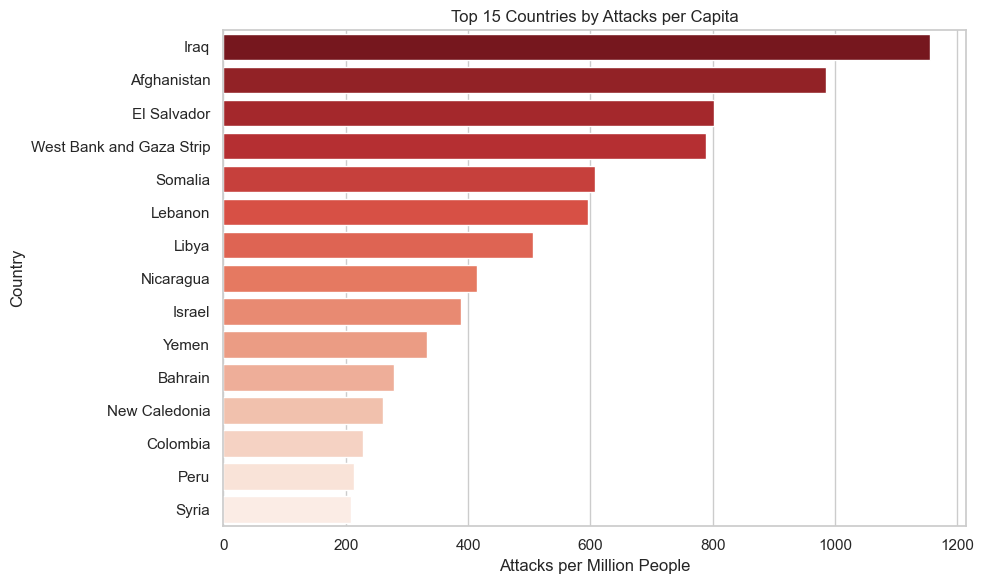

In [172]:
terror['attacks_per_million'] = 1 / (terror['mean_population_1971to21'] / 1_000_000)

attacks_per_country_meanpop = (
    terror.groupby('country_txt')['attacks_per_million']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(x=attacks_per_country_meanpop.values, y=attacks_per_country_meanpop.index, palette='Reds_r')
plt.xlabel("Attacks per Million People")
plt.ylabel("Country")
plt.title("Top 15 Countries by Attacks per Capita")

plt.tight_layout()
plt.show()

#### Top Countries affected per capita in a year

Lets look at the top 15 countries affected in the specified year, normalized using its population in that year.

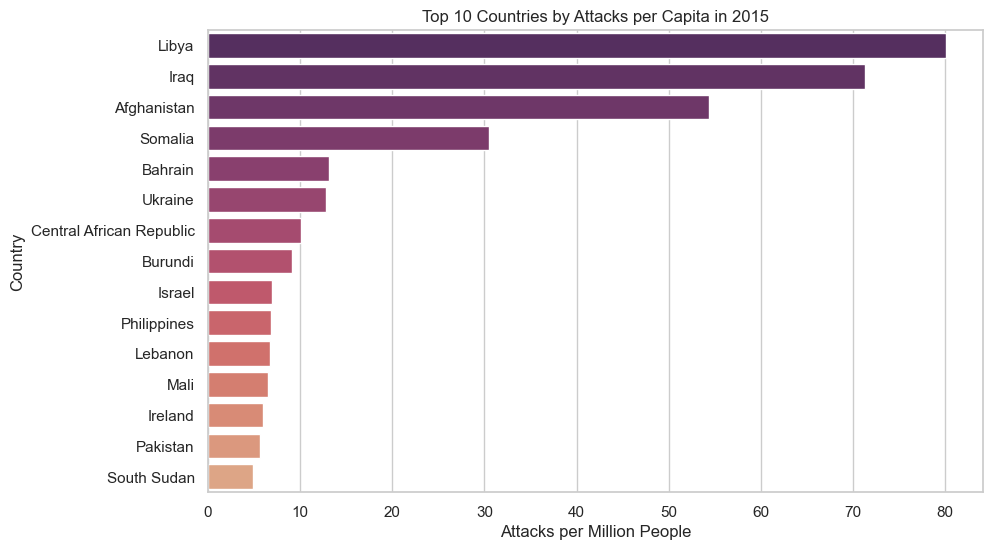

In [173]:
year = 2015

terror_year = terror[terror['year'] == year]

attacks_per_country = (
    terror_year.groupby('country_txt')
    .size()
    .reset_index(name='attack_count')
)

population_year = population_long[population_long['year'] == year][['Country Name', 'population']]
attacks_per_country = attacks_per_country.merge(population_year, left_on='country_txt', right_on='Country Name', how='left')

attacks_per_country['attacks_per_million'] = attacks_per_country['attack_count'] / (attacks_per_country['population'] / 1_000_000)

top_attacks_per_capita = attacks_per_country.sort_values('attacks_per_million', ascending=False).head(15)


plt.figure(figsize=(10,6))
sns.barplot(x=top_attacks_per_capita['attacks_per_million'], y=top_attacks_per_capita['country_txt'], palette='flare_r')
plt.xlabel("Attacks per Million People")
plt.ylabel("Country")
plt.title(f"Top 10 Countries by Attacks per Capita in {year}")
plt.show()

We can see that by changing our perspective from just the number of attacks to the actual impact of this number of attacks on the country by normalizing it with the population we can see a drastic change in the top 15 countries.

The above block of code is customizable to any year by just changing the ``year`` variable at the start.

### Casualty Fields

Lets look at the casualty of attacks in the dataset using fields like ``nkill`` and `nwound`.

In [174]:
terror.nkill.describe()


count    193473.000000
mean          2.519876
std          11.463546
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max        1700.000000
Name: nkill, dtype: float64

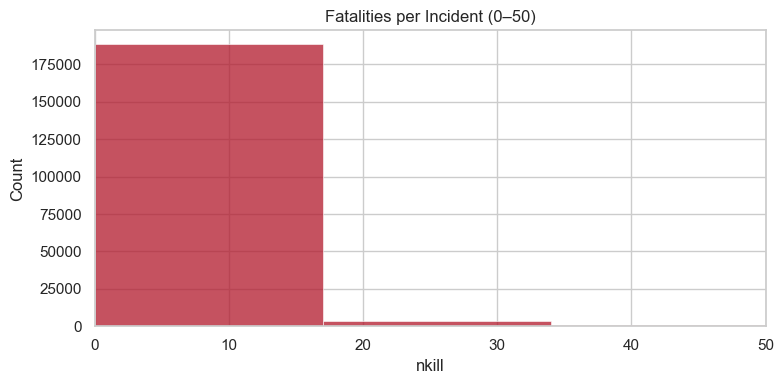

In [175]:
plt.figure(figsize=(8,4))
sns.histplot(terror['nkill'].dropna(), bins=100, color=PRIMARY_COLOR)
plt.xlim(0,50)     # zoom to show typical distribution
plt.title('Fatalities per Incident (0–50)')
plt.tight_layout()

We can observe that most events have <20 fatalities.

#### Temporal Distribution of Killed vs Wounded

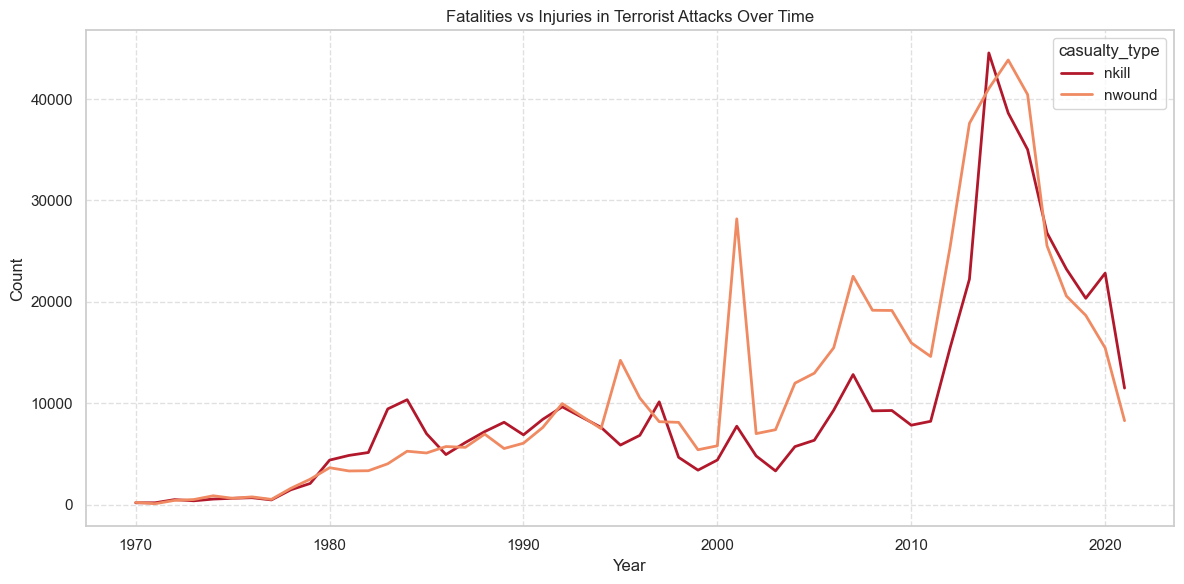

In [176]:
# Group by year and sum fatalities and injuries
casualties_per_year = (
    terror.groupby('year')[['nkill', 'nwound']]
    .sum()
    .reset_index()
)

# Melt to long format for seaborn
casualties_long = casualties_per_year.melt(
    id_vars='year', 
    value_vars=['nkill', 'nwound'], 
    var_name='casualty_type', 
    value_name='count'
)



# Plot with seaborn
plt.figure(figsize=(12,6))
sns.lineplot(
    data=casualties_long,
    x='year', y='count', hue='casualty_type',
    linewidth=2,
    
    palette={
        "nkill": PRIMARY_COLOR,
        "nwound": "#ef8a62"
    }
    
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Fatalities vs Injuries in Terrorist Attacks Over Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

This shows a lineplot with the `nkill` and `nwound` fields over the years worldwide. We can see a spike in the data in the years between 2010 and 2020 with a sharp decline after the peak.

#### Top 15 countries with most casualty impact per capita

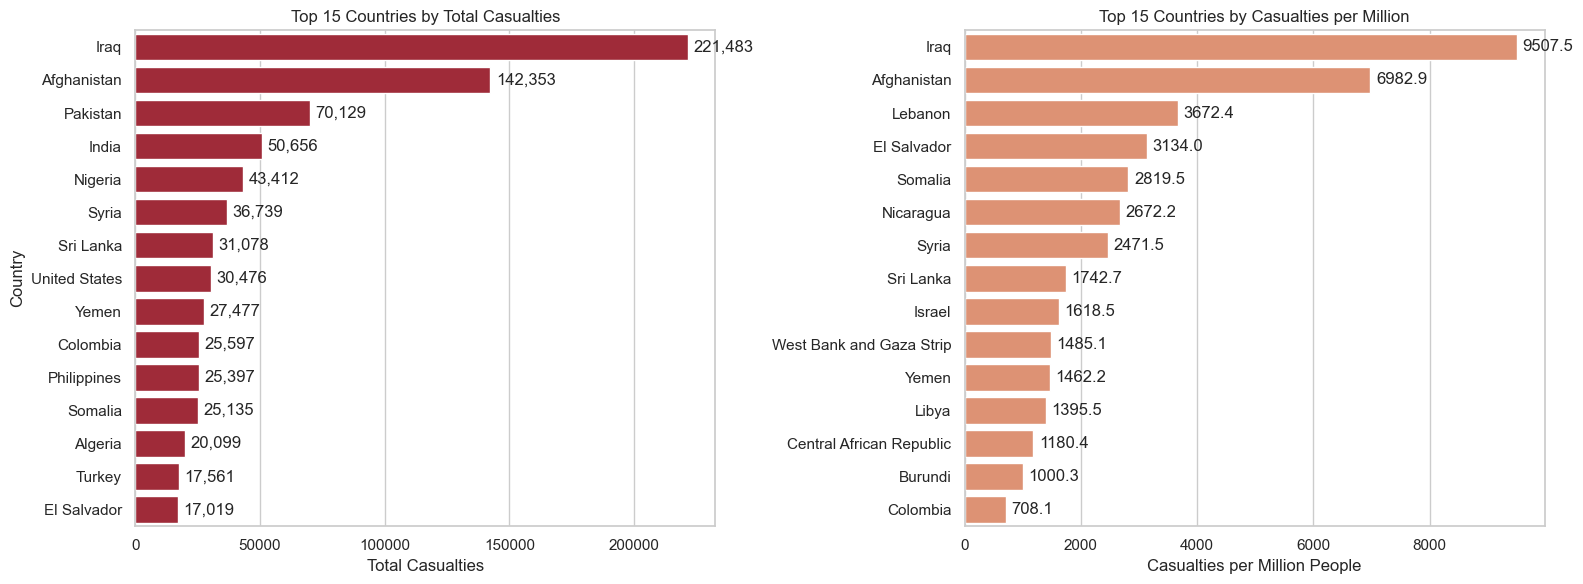

In [177]:
# Calculate total casualties
terror["casualties"] = terror["nkill"].fillna(0) + terror["nwound"].fillna(0)

# Casualties per million population
terror["casualties_per_million"] = (
    terror["casualties"] / (terror["mean_population_1971to21"] / 1_000_000)
)

# Aggregate
total_casualties_country = (
    terror.groupby("country_txt")["casualties"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

per_capita_casualties_country = (
    terror.groupby("country_txt")["casualties_per_million"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

sns.barplot(
    x=total_casualties_country.values,
    y=total_casualties_country.index,
    color=PRIMARY_COLOR,
    ax=axes[0]
)

axes[0].set_title("Top 15 Countries by Total Casualties")
axes[0].set_xlabel("Total Casualties")
axes[0].set_ylabel("Country")

for i, v in enumerate(total_casualties_country.values):
    axes[0].text(v + 0.01 * total_casualties_country.max(), i, f"{int(v):,}", va="center")


sns.barplot(
    x=per_capita_casualties_country.values,
    y=per_capita_casualties_country.index,
    color="#ef8a62",
    ax=axes[1]
)

axes[1].set_title("Top 15 Countries by Casualties per Million")
axes[1].set_xlabel("Casualties per Million People")
axes[1].set_ylabel("")

for i, v in enumerate(per_capita_casualties_country.values):
    axes[1].text(v + 0.01 * per_capita_casualties_country.max(), i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.show()

**Observation:**
While countries like Iraq and Afghanistan dominate in total casualties due to sustained conflict, population-normalized metrics reveal a different reality. Smaller regions such as El Salvador and the West Bank & Gaza Strip experience a far higher per-capita casualty burden, showing that terrorism’s impact can be disproportionately severe even where total counts are lower. This comparison demonstrates why normalizing by population is essential to understanding the true human cost of terrorism.


### Perpetrators

Lets analyze data regarding the most active terrorist groups using the `gname` field.

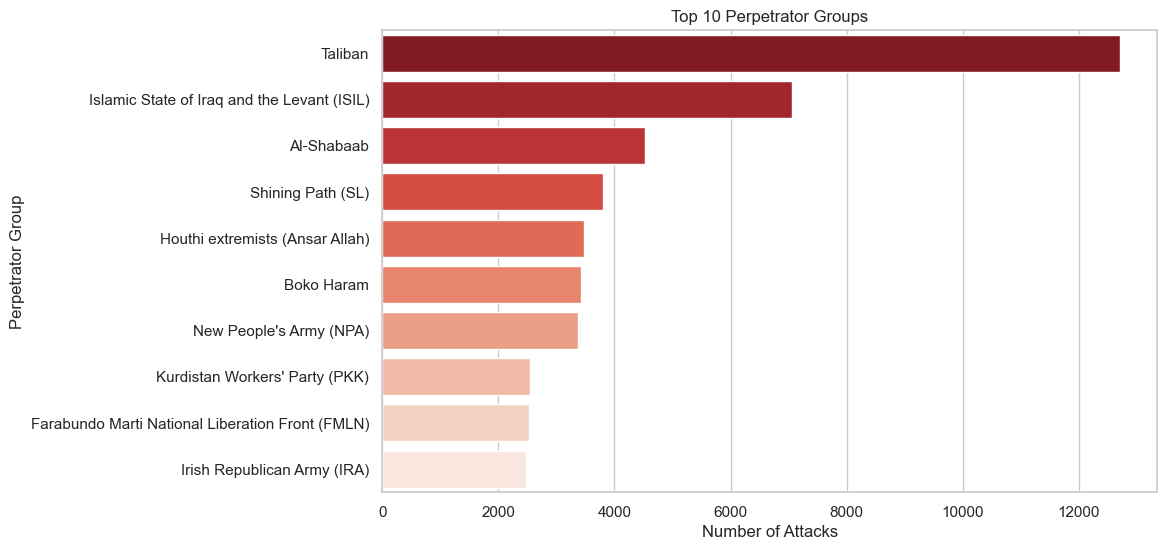

In [178]:
top_gnames = terror['gname'].value_counts().head(11)
top_gnames = top_gnames.drop("Unknown")

plt.figure(figsize=(10,6))
sns.barplot(x=top_gnames.values, y=top_gnames.index, palette='Reds_r')
plt.xlabel("Number of Attacks")
plt.ylabel("Perpetrator Group")
plt.title("Top 10 Perpetrator Groups")
plt.show()

In [179]:
#Percentage of attacks with unknown perpetrator group.

unknown_pct = (terror['gname'] == 'Unknown').mean() * 100
print(f"Percentage of attacks with unknown perpetrator: {unknown_pct:.2f}%")

Percentage of attacks with unknown perpetrator: 44.21%


Lets do a lineplot to show the frequency of attacks carried out by top 10 perpetrator groups throughout the years.

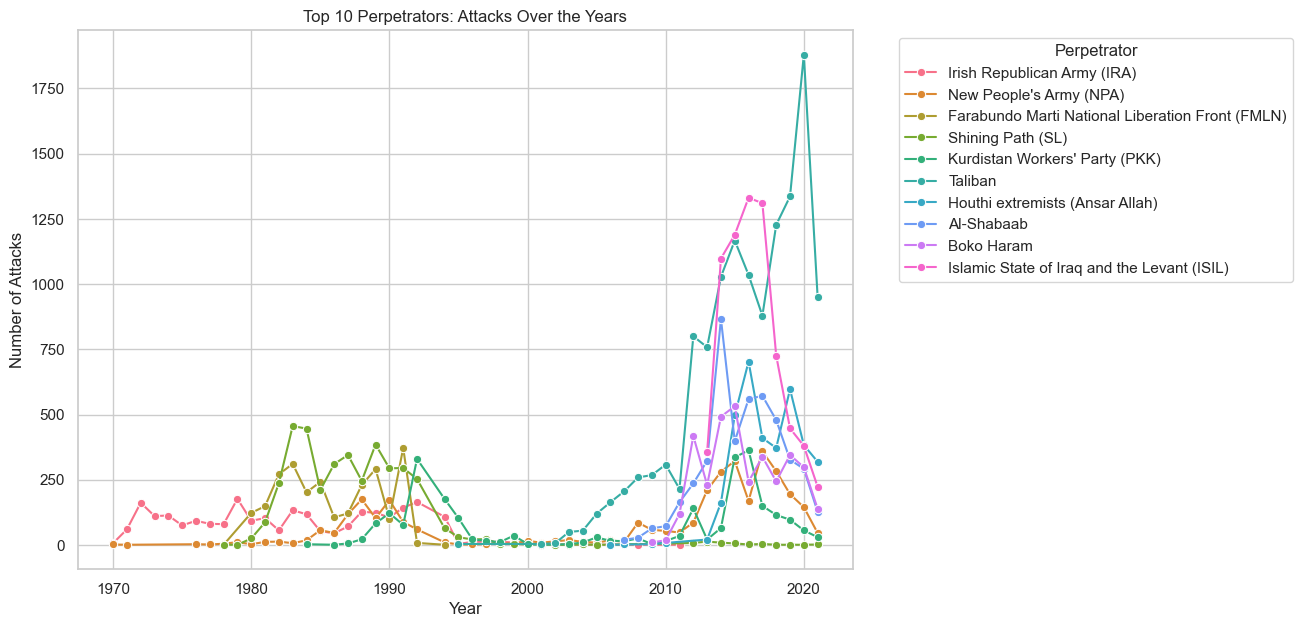

In [180]:
top10_list = top_gnames.index.tolist()
terror_top10 = terror[terror['gname'].isin(top10_list)]

group_year = terror_top10.groupby(['year','gname']).size().reset_index(name='attack_count')

plt.figure(figsize=(10,7))
sns.lineplot(data=group_year, x='year', y='attack_count', hue='gname', marker='o')
plt.title("Top 10 Perpetrators: Attacks Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.legend(title='Perpetrator', bbox_to_anchor=(1.05, 1))
plt.show()


Lets check if the top 10 groups have any geographical associations (if the attacks are focused in one region).

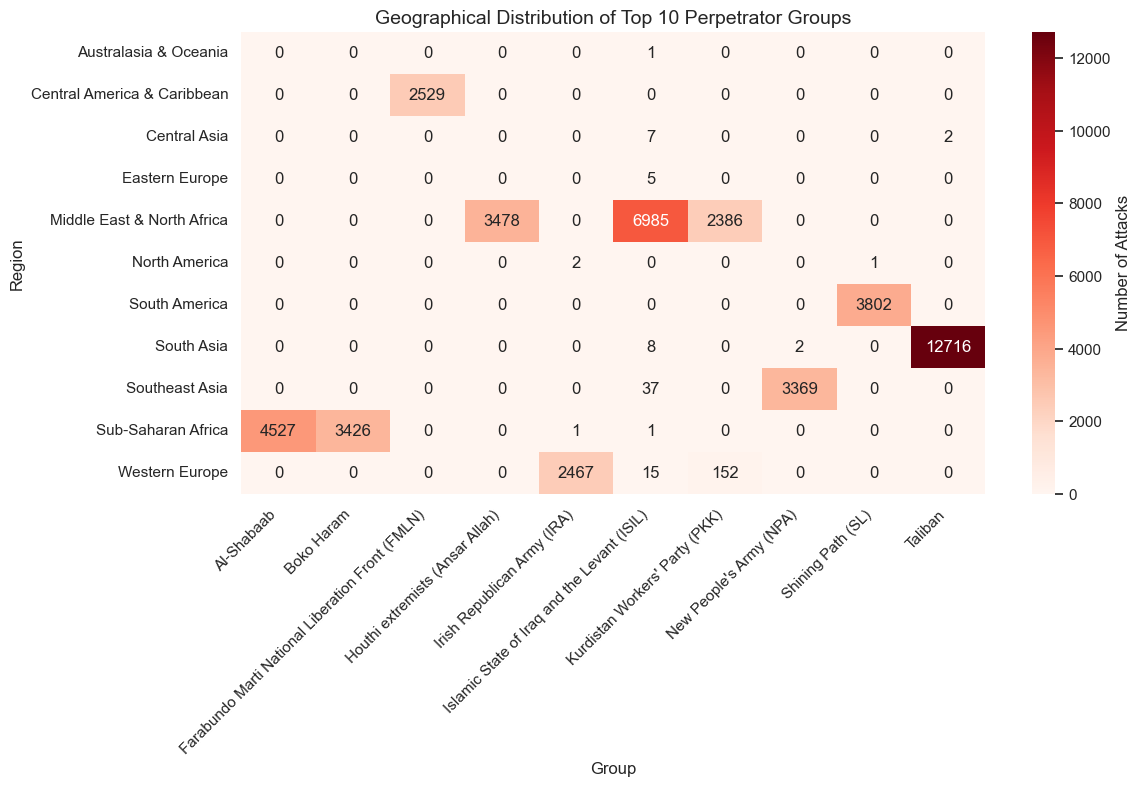

In [181]:
geo_group = (
    terror[terror['gname'].isin(top10_list)]
    .groupby(['region_txt','gname'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))
sns.heatmap(
    geo_group, cmap="Reds", annot=True, fmt="d", 
    cbar_kws={'label': 'Number of Attacks'}
)
plt.title("Geographical Distribution of Top 10 Perpetrator Groups", fontsize=14)
plt.xlabel("Group")
plt.ylabel("Region")
plt.xticks(rotation=45, ha="right")
plt.show()


As we can see in the generated heatmap, it is evident that all of the major perpretators have a geographical association. This suggests that terrorism is often shaped by a localized geopolitical, cultural, and socio-economic factors rather than being distributed worldwide.

This kind of **regional clustering** indicates that,

- Groups tend to emerge, operate and sustain their influence within their home region.

- Policies and counter-terrorism strategies therefore need to be region-specific, as global approaches may overlook local dynamics.

Let's now look at the longevity and timespan of the top 10 terrorist groups.

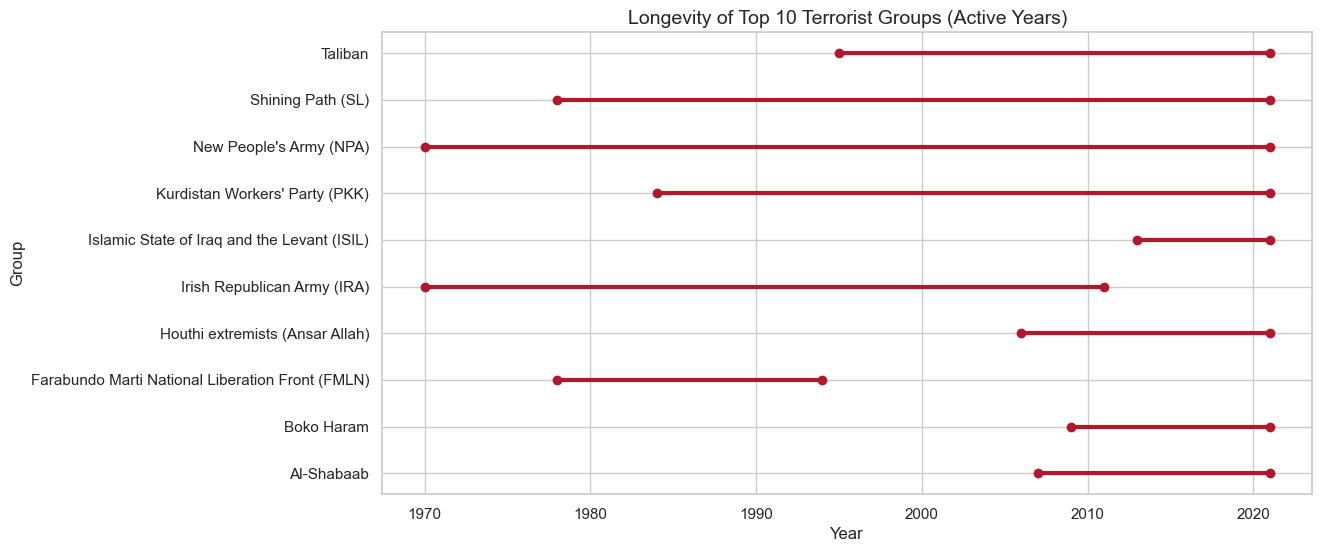

In [182]:
# First and last year of activity for each group
longevity = (
    terror[terror['gname'].isin(top10_list)]
    .groupby('gname')['year']
    .agg(['min','max'])
    .reset_index()
)

plt.figure(figsize=(12,6))
for i, row in longevity.iterrows():
    plt.plot(
        [row['min'], row['max']], 
        [row['gname'], row['gname']], 
        marker='o', linewidth=3,
        color = PRIMARY_COLOR
    )

plt.xlabel("Year")
plt.ylabel("Group")
plt.title("Longevity of Top 10 Terrorist Groups (Active Years)", fontsize=14)
plt.show()

**Observation:**
The timeline reveals striking differences in how long perpetrator groups have remained active. Some organizations like **ISIS (ISIL)** and the **New People’s Army (NPA)** display remarkable persistence, operating across multiple decades and adapting to evolving geopolitical conditions. In contrast, groups such as the **Irish Republican Army (IRA)**, once highly active, saw their activity decline and effectively disappear around 2010, illustrating how peace processes and political integration can dissolve long-standing insurgencies. The **Kurdistan Worker's Party (PKK)**, which emerged later in the early 1980s, demonstrates another path of longevity, remaining a significant regional actor despite sustained counterterrorism campaigns.

Overall, the plot emphasizes that while most groups are **short-lived and opportunistic**, a few evolve into enduring threats with deep ideological or separatist foundations, capable of outlasting governments, policy shifts, and even international coalitions.

Lets look at the 20 most lethal groups and compare them.

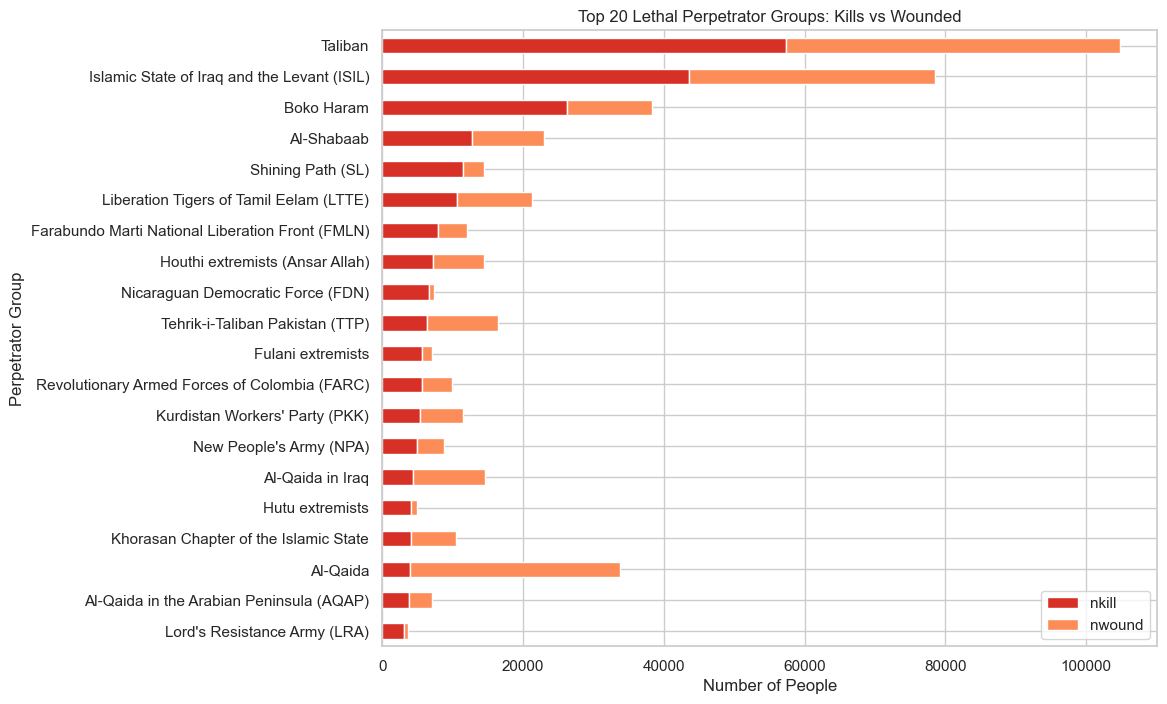

In [183]:
colors = ['#d73027', '#fc8d59']

terror_groups = (
    terror[terror["gname"] != "Unknown"].groupby("gname")[["nkill", "nwound"]]
    .sum()
    .sort_values("nkill", ascending=False)
    .head(20)
)

terror_groups[['nkill','nwound']].sort_values('nkill', ascending=True).plot(
    kind='barh',
    stacked=True,
    figsize=(10,8),
    color=colors
)

plt.xlabel("Number of People")
plt.ylabel("Perpetrator Group")
plt.title("Top 20 Lethal Perpetrator Groups: Kills vs Wounded")
plt.show()

The stacked barplot shows the casualty profile of top perpetrator groups. The Taliban has the highest and most balanced lethality, with slightly more kills than wounds. ISIS and Boko Haram cause more deaths than injuries, while Al Qaeda has the highest wound-to-kill ratio. Overall, a few groups account for the majority of casualties.

#### Lethality Index

Let us develop a normalized measure for group lethality that helps us highlight the lethality per event which will be irrespective of timespan or number of terrorist events.

`lethality = (total_kills + total_wounded) / number_of_incidents`

Lets plot a graph based on that.

Variables used:
- number killed
- number wounded
- perpetrator name

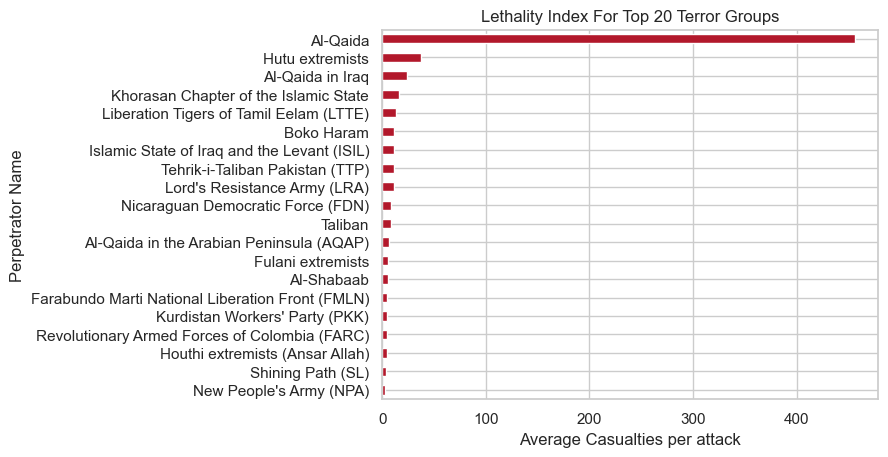

In [184]:
group_incidents = (
    terror
    .groupby("gname")
    .size()
    .rename("n_incidents")
)

group_impact = (
    terror_groups
    .merge(group_incidents, left_index=True, right_index=True)
)

#Creating a new column for our lethality index

group_impact["lethality_index"]= (group_impact["nkill"] + group_impact["nwound"]) / group_impact["n_incidents"]

group_impact.sort_values("lethality_index", ascending=True)["lethality_index"].plot(
    kind="barh",
    color= "#b2182b"
)

plt.xlabel("Average Casualties per attack")
plt.ylabel("Perpetrator Name")
plt.title("Lethality Index For Top 20 Terror Groups")
plt.show()


    

**Observation:** 
When adjusted for the number of attacks, certain groups stand out as significantly more lethal per incident, suggesting a strategy focused on high-impact operations rather than attack frequency. Al-Qaida emerges as the most lethal group, likely due to its involvement in large-scale attacks resulting in numerous casualties.

### Boolean Data Analysis

Lets look at some boolean data that gives us some information about terrorist attacks.

In [185]:
event_cols = ['success', 'suicide', 'multiple', 'claimed', 'ishostkid', 'nreleased']  # add more as needed
event_data = terror[event_cols]

event_percent = event_data.apply(lambda x: x.value_counts(normalize=True).get(1, 0) * 100)
event_percent = event_percent.sort_values(ascending=False)
event_percent

success      88.209516
nreleased    18.803665
claimed      17.170950
multiple     11.893285
ishostkid     8.254268
suicide       3.644004
dtype: float64

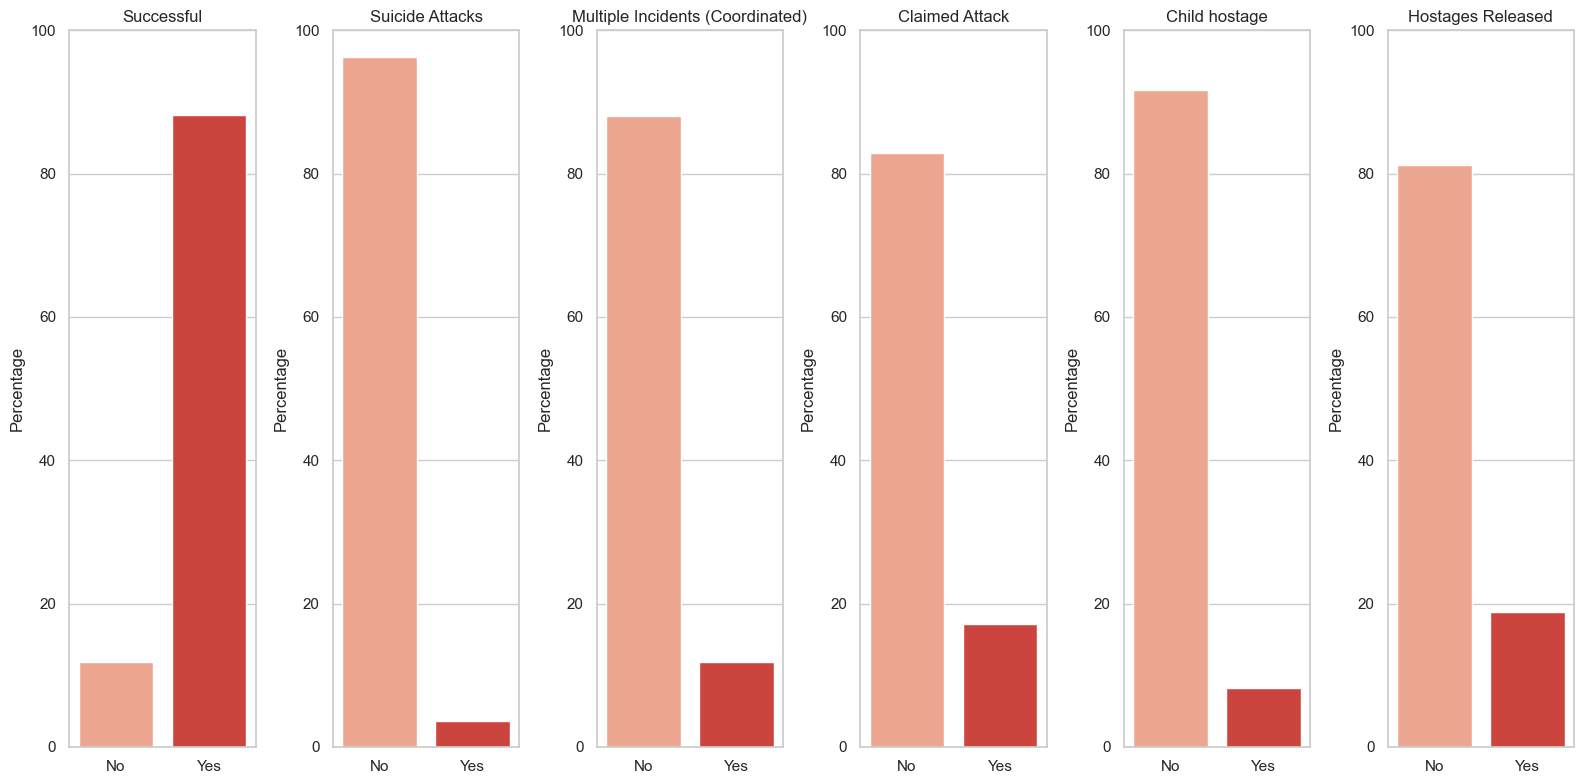

In [186]:
custom_titles = {
    'success': 'Successful',
    'suicide': 'Suicide Attacks',
    'multiple': 'Multiple Incidents (Coordinated)',
    'claimed': 'Claimed Attack',
    'ishostkid': 'Child hostage',
    'nreleased': 'Hostages Released'
}

fig, axes = plt.subplots(1, len(event_cols), figsize=(16,8))

for i, col in enumerate(event_cols):
    sns.barplot(
        x=[0,1],
        y=[100-event_percent[col], event_percent[col]],
        ax=axes[i],
        palette='Reds'
    )
    axes[i].set_title(custom_titles[col])      # Set custom title
    axes[i].set_xticklabels(['No','Yes'])      # Custom x-axis labels
    axes[i].set_ylim(0,100)
    axes[i].set_ylabel('Percentage')

plt.tight_layout()
plt.show()


**Observations:**
- 88.2% of attacks were successful.
- 18.8% of attacks reported that hostages were released.
- Only 17.2% of attacks were claimed by terrorist groups.
- 11.9% of terrorist attacks included multiple co-ordinated incidents.
- 8.2% of attacks involved a kid as hostage.
- 3.6% of attacks were suicide attacks.

## 💡 Insights and Key Findings

Throughout this exploratory analysis of the **Global Terrorism Database** (1970–2021), several meaningful patterns emerged that help tell a nuanced story about the dynamics of terrorism over time, across regions, and between perpetrator groups.


#### 1. Weapon Usage Reflects Tactical Preferences and Regional Conflict Styles
Our analysis showed that explosives dominate as the primary weapon type globally, suggesting that bombings and similar attack modes have been consistently preferred across many conflicts. However, when we break this down geographically, notable regional patterns emerge:

- Central America & the Caribbean, Southeast Asia, and Sub‑Saharan Africa exhibit a higher proportion of firearms attacks, indicating conflicts where small arms and direct engagements were more common.
- Incendiary attacks, when examined in detail, reveal more nuanced patterns:

    - In Sub-Saharan Africa, incendiary attacks are primarily focused on residential areas in villages and towns,
     indicating a strategy targeting civilian property and disrupting local communities.

    - In South Asia, they concentrate on public infrastructure such as government buildings, schools, and buses, reflecting a focus on symbolic or societal disruption.

    - In Western Europe, incendiary attacks are more scattered and do not follow a clear pattern, suggesting isolated or opportunistic incidents rather than coordinated campaigns.

These patterns suggest that weapon choice is not random but linked to the type of conflict environment, availability of weapons, and strategic goals of actors in each region.

This regional variation deepens our understanding that terrorism is not uniform, even if explosive inclined globally, local conditions shape how violence unfolds.


#### 2. Lethality != Frequency, rather about Intent and Capacity

The **lethality index** — calculated as average casualties per incident revealed a striking pattern:

    Groups with fewer total incidents can be far more deadly per attack than high‑frequency perpetrators.

For instance, Al‑Qaida emerged as the most lethal group in terms of average casualties per incident, despite engaging in fewer total attacks than some others. This suggests a strategic focus on high‑impact events, rather than a sheer volume of low‑impact engagements.

This insight challenges simplistic rankings of “most active” groups and instead highlights those whose tactics lead to disproportionately severe outcomes.

#### 3. Regional Growth Trends Highlight Uneven Evolution of Terrorism

Temporal trends in the data show distinct phases in the evolution of terrorism:

- Some regions experienced sharp increases in attacks in certain decades, while others saw relative stabilization or decline.

- These shifts often align with geopolitical events (e.g., proxy wars, insurgencies, transitions in governance), underscoring that terrorism trends must be interpreted in historical context.

By pairing attack volume with lethality and weapon trends, we can see how terrorism has not only grown in frequency in some areas but also evolved in modus operandi.


#### 4. Per Capita Effect of Terrorism

By combining the GTD with global population data, we were able to normalize casualties by population, highlighting countries disproportionately impacted by terrorism. This effort allows us to see the **per-person impact**, not just the total number of attacks.

While high-incident countries like Afghanistan and Iraq report large total number of incidents, smaller or mid-sized countries such as El Salvador and the Gaza Strip experience far higher casualties per million population, revealing a severe per-person cost.

Over time, this per capita metric shows how terrorism intensity shifts across regions, uncovering not only where attacks are frequent but also where they hit communities hardest relative to population. This perspective provides a more vital understanding of the human cost of terrorism, complementing absolute attack counts and lethality metrics.


#### 5. Limitations and Opportunities for Future Analysis

While this EDA uncovered numerous patterns in attack types, lethality, and geographic distribution, the GTD has inherent limitations that shape what conclusions we can draw. Some categories, such as rare weapon types or small terrorist groups, contain too few entries to support statistically robust analyses. Additionally, reporting biases, missing values, and inconsistent classification across countries and time periods can influence observed trends.

Future work could extend this analysis by integrating socioeconomic, political, or conflict-related indicators, exploring temporal shifts in tactics, or examining perpetrator networks. Normalizing metrics by population, infrastructure, or regional context is one example of how deeper, context-aware analyses could yield more refined insights. This highlights that while EDA can reveal patterns, careful interpretation and complementary data are essential to fully understand the drivers and consequences of terrorism.

## Conclusion

This EDA of the Global Terrorism Database provides a multi-faceted view of global terrorism patterns over the last five decades. From basic univariate distributions to complex bivariate analyses, we observed how attack types, lethality, and target selection vary across regions, terrorist groups, and time. Normalizing metrics by population and incident count highlighted the **disproportionate human impact** in smaller countries and the **relative lethality** of certain groups, providing insights beyond raw counts.

While the analysis uncovered meaningful trends such as the **concentration of incendiary attacks** in Sub-Saharan Africa and South Asia, or the high per-incident lethality of groups like Al Qaida, it also underscores the limitations of available data, including reporting biases, missing entries, and underrepresented categories. These constraints point toward rich opportunities for future work, such as incorporating socioeconomic indicators, temporal trends, or network analyses of perpetrators.

Overall, this study demonstrates that a careful, layered exploration of terrorism data can reveal not only where attacks occur most frequently, but also where they are most deadly, impactful, and strategically significant, providing a more nuanced understanding of global terrorism dynamics.